# Math 189 Final Project Code

## Data Cleaning

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic

df = pd.read_csv("full_housing_data.csv")

df.head()

,Unnamed: 0,address,addressZipcode,addressStreet,area,baths,beds,latitude,longitude,monthly_rent,...,ucsd_car_time,ucsd_transit_dist,ucsd_transit_time,nearest_grocery,grocery_car_dist,grocery_car_time,coast_dist_km,medNeighborhoodIncome,zip_code,avg_crime
0,0,"Vadara West, 2724 El Cajon Blvd #402, San Dieg...",92104,2724 El Cajon Blvd #402,795.0,1.0,1.0,32.755623,-117.134330,2995,...,20 mins,27.6 km,1 hour 8 mins,Whole Foods Market,2.9 km,8 mins,11.041507,92862,92104.0,1.336323
1,1,"Fashion Terrace, 6888 Friars Rd, San Diego, CA...",92108,6888 Friars Rd,1038.0,2.0,2.0,32.769010,-117.172070,3100,...,16 mins,19.4 km,45 mins,Whole Foods Market,4.1 km,7 mins,7.417457,101704,92108.0,21.679286
2,2,"Esprit Villas, 9830 Reagan Rd #60b404513, San ...",92126,9830 Reagan Rd #60b404513,950.0,2.0,2.0,32.909718,-117.147400,2895,...,17 mins,14.6 km,43 mins,H Mart,3.5 km,10 mins,10.119282,123232,92126.0,0.744286
3,3,"The Royal of Rancho Penasquitos, 9808 Paseo Mo...",92129,9808 Paseo Montalban #27,982.0,2.0,2.0,32.962887,-117.117490,3095,...,17 mins,23.6 km,1 hour 4 mins,H Mart,6.3 km,9 mins,13.790490,152626,92129.0,0.508201
4,4,"10632 Quill Ct, San Diego, CA 92126",92126,10632 Quill Ct,1943.0,4.0,3.0,32.897533,-117.165726,5680,...,15 mins,13.9 km,1 hour 0 mins,H Mart,7.2 km,14 mins,8.191808,123232,92126.0,0.744286


We observe basic attributes about our dataset below.

In [4]:
print(df.shape)
print(df.dtypes)
print(df.describe())

(1613, 24)
Unnamed: 0                 int64
address                   object
addressZipcode             int64
addressStreet             object
area                     float64
baths                    float64
beds                     float64
latitude                 float64
longitude                float64
monthly_rent               int64
nearest_transit           object
transit_walk_dist         object
transit_walk_time         object
ucsd_car_dist             object
ucsd_car_time             object
ucsd_transit_dist         object
ucsd_transit_time         object
nearest_grocery           object
grocery_car_dist          object
grocery_car_time          object
coast_dist_km            float64
medNeighborhoodIncome      int64
zip_code                 float64
avg_crime                float64
dtype: object
        Unnamed: 0  addressZipcode          area        baths         beds  \
count  1613.000000     1613.000000   1613.000000  1613.000000  1613.000000   
mean    806.000000    92104

We now check for any null values that may distort our findings.

In [5]:
print(df.isnull().sum())

Unnamed: 0                 0
address                    0
addressZipcode             0
addressStreet              0
area                       0
baths                      0
beds                       0
latitude                   0
longitude                  0
monthly_rent               0
nearest_transit            0
transit_walk_dist          0
transit_walk_time          0
ucsd_car_dist              0
ucsd_car_time              0
ucsd_transit_dist        124
ucsd_transit_time        124
nearest_grocery            0
grocery_car_dist           0
grocery_car_time           0
coast_dist_km              0
medNeighborhoodIncome      0
zip_code                  22
avg_crime                 22
dtype: int64


As can be seen, variables ucsd_transit_dist, ucsd_transit_time, zip_code, and avg_crime have null values. We remove observations from our dataset in which this is the case. After, we confirm the accuracy of our action by printing the sum of null observations for each category. Since all are zero, our code is successful.

In [6]:
df = df.dropna(subset=['ucsd_transit_dist', 'ucsd_transit_time', 'zip_code', 'avg_crime'])
print(df.isnull().sum())

Unnamed: 0               0
address                  0
addressZipcode           0
addressStreet            0
area                     0
baths                    0
beds                     0
latitude                 0
longitude                0
monthly_rent             0
nearest_transit          0
transit_walk_dist        0
transit_walk_time        0
ucsd_car_dist            0
ucsd_car_time            0
ucsd_transit_dist        0
ucsd_transit_time        0
nearest_grocery          0
grocery_car_dist         0
grocery_car_time         0
coast_dist_km            0
medNeighborhoodIncome    0
zip_code                 0
avg_crime                0
dtype: int64


Now, we will check for significant outliers, innaccurate values for apartment attributes, and duplicates.

count     1467.000000
mean      5823.347648
std       6151.917866
min        615.000000
25%       2950.000000
50%       4225.000000
75%       6370.500000
max      85000.000000
Name: monthly_rent, dtype: float64

Listings under $500: 0
Listings over $10,000: 133

Zero bed listings: 0
Zero bath listings: 0
Zero area listings: 0

Duplicate addresses: 0


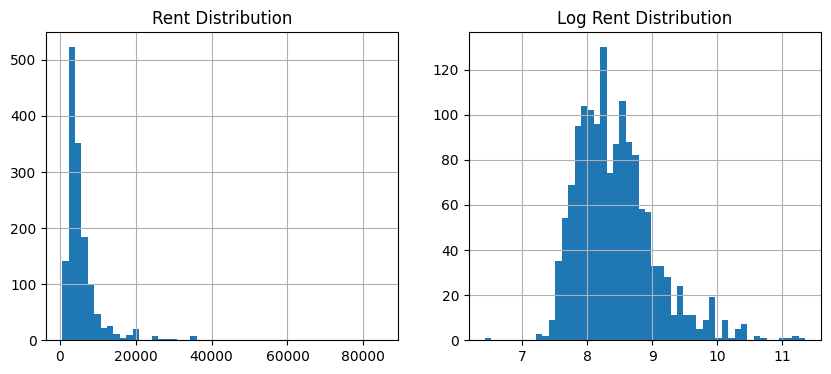

In [7]:
# Rent outliers
print(df['monthly_rent'].describe())
print(f"\nListings under $500: {len(df[df['monthly_rent'] < 500])}")
print(f"Listings over $10,000: {len(df[df['monthly_rent'] > 10000])}")

# Strange beds/baths/area values
print(f"\nZero bed listings: {len(df[df['beds'] == 0])}")
print(f"Zero bath listings: {len(df[df['baths'] == 0])}")
print(f"Zero area listings: {len(df[df['area'] == 0])}")

# Duplicates
print(f"\nDuplicate addresses: {df['addressStreet'].duplicated().sum()}")

# Rent distribution to visualize any more abnormalities
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
df['monthly_rent'].hist(bins=50)
plt.title('Rent Distribution')
plt.subplot(1,2,2)
np.log(df['monthly_rent']).hist(bins=50)
plt.title('Log Rent Distribution')
plt.show()

Since there are a few outliers, we will remove those. However, there are no strange values for apartment attributes nor duplicates.

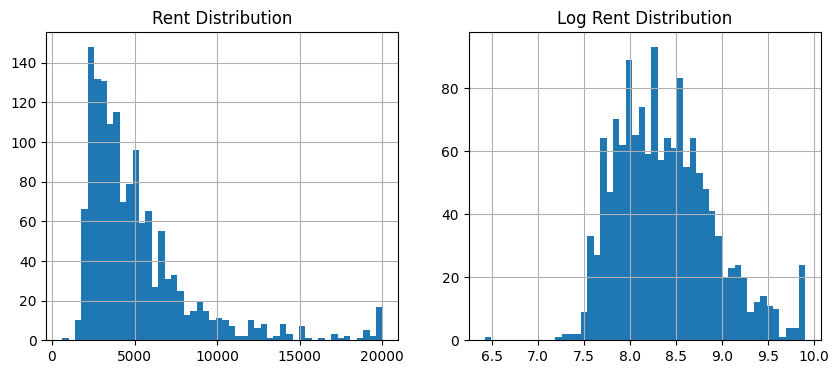

In [8]:
df = df[df['monthly_rent'] <= 20000]

# Rent distribution
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
df['monthly_rent'].hist(bins=50)
plt.title('Rent Distribution')
plt.subplot(1,2,2)
np.log(df['monthly_rent']).hist(bins=50)
plt.title('Log Rent Distribution')
plt.show()